# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BilaalBakare/Flyrank-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*


The queue: what to do first, and why

Pages are ranked by impressions — the more visibility a page already has, the more potential upside if the underlying issue is fixed. Two reason codes cover distinct situations that need different treatment, not one blanket flag:

ZERO_CLICKS_WITH_VISIBILITY → review_content_quality — the page gets real impressions but literally zero clicks. This is treated separately from a CTR problem because zero clicks despite visibility can indicate a deeper issue (irrelevant content, wrong intent match, thin page) that a title/snippet tweak won't fix. This needs a human content review before any specific action is chosen.
POOR_POSITION_WITH_VISIBILITY → improve_ctr — position 21+, with CTR below the March portfolio average. This is the more mechanical case: the page ranks poorly but has clicks, so a title/snippet refinement is a reasonable first attempt.

Pages with healthy CTR relative to their position (like high-impression pages already converting well — flagged as weak picks in Week 4) are deliberately excluded from this queue, even if they have high impressions, because flagging already-healthy pages wastes review time and erodes trust in the queue.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from dotenv import load_dotenv
import os
import duckdb

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
rel = "hf://datasets/FlyRank/internship-warehouse"


In [3]:
playbook_df = con.sql(f"""
    WITH base AS (
        SELECT
            client_hash_id,
            content_hash_id,
            report_date,
            gsc_avg_position,
            gsc_impressions,
            gsc_clicks,
            gsc_clicks * 1.0 / NULLIF(gsc_impressions, 0) AS ctr
        FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
        WHERE month = '2026-03'
          AND gsc_avg_position IS NOT NULL
          AND gsc_impressions >= 50
    ),
    bucket_avg AS (
        SELECT AVG(ctr) AS overall_avg_ctr FROM base
    ),
    scored AS (
        SELECT
            base.*,
            bucket_avg.overall_avg_ctr,
            CASE
                WHEN base.gsc_clicks = 0 THEN 'ZERO_CLICKS_WITH_VISIBILITY'
                WHEN base.gsc_avg_position >= 21 AND base.ctr < bucket_avg.overall_avg_ctr THEN 'POOR_POSITION_WITH_VISIBILITY'
                ELSE NULL
            END AS reason_code,
            CASE
                WHEN base.gsc_clicks = 0 THEN 'review_content_quality'
                WHEN base.gsc_avg_position >= 21 AND base.ctr < bucket_avg.overall_avg_ctr THEN 'improve_ctr'
                ELSE NULL
            END AS action,
            base.gsc_impressions AS score
        FROM base, bucket_avg
    )
    SELECT *
    FROM scored
    WHERE reason_code IS NOT NULL
    ORDER BY score DESC
""").df()

playbook_df.head(20)

,client_hash_id,content_hash_id,report_date,gsc_avg_position,gsc_impressions,gsc_clicks,ctr,overall_avg_ctr,reason_code,action,score
0,client_62f4a7e64f5e0096,content_945d6ff91386c817,2026-03-04,8.613948,37368,0,0.0,0.00306,ZERO_CLICKS_WITH_VISIBILITY,review_content_quality,37368
1,client_73cda7b4e4f265ea,content_fec55986a1868d62,2026-03-30,0.181500,33383,0,0.0,0.00306,ZERO_CLICKS_WITH_VISIBILITY,review_content_quality,33383
2,client_23a62021009f63c4,content_44f34c0a90047651,2026-03-27,0.132532,32958,0,0.0,0.00306,ZERO_CLICKS_WITH_VISIBILITY,review_content_quality,32958
3,client_73cda7b4e4f265ea,content_fec55986a1868d62,2026-03-31,0.083407,31472,0,0.0,0.00306,ZERO_CLICKS_WITH_VISIBILITY,review_content_quality,31472
4,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,2026-03-02,0.000311,28973,0,0.0,0.00306,ZERO_CLICKS_WITH_VISIBILITY,review_content_quality,28973
5,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,2026-03-01,0.002245,28947,0,0.0,0.00306,ZERO_CLICKS_WITH_VISIBILITY,review_content_quality,28947
6,client_62f4a7e64f5e0096,content_34a70fea29d15f24,2026-03-22,3.129405,27410,0,0.0,0.00306,ZERO_CLICKS_WITH_VISIBILITY,review_content_quality,27410
7,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,2026-03-03,0.317996,24233,0,0.0,0.00306,ZERO_CLICKS_WITH_VISIBILITY,review_content_quality,24233
8,client_e547b89c05043229,content_757b1fa67827358d,2026-03-13,2.261644,19301,0,0.0,0.00306,ZERO_CLICKS_WITH_VISIBILITY,review_content_quality,19301
9,client_73cda7b4e4f265ea,content_fec55986a1868d62,2026-03-24,0.013056,17770,0,0.0,0.00306,ZERO_CLICKS_WITH_VISIBILITY,review_content_quality,17770


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Who uses this: A content strategist or SEO lead, as a starting point for prioritizing manual review — not an automated action list. It answers "where should I look first?", not "what should I do without checking?"

What it's for: Surfacing pages that already have real search visibility (meaningful impressions) but aren't converting that visibility into clicks, so limited review time goes to the pages with the most recoverable upside first.

Where it stops being valid:

Single client, single month. This slice is drawn almost entirely from one client (client_23a62021009f63c4, confirmed in Week 4) over March 2026 only. It has not been validated against other clients, other months, or seasonal variation — a different client or time period could show a different pattern entirely.
No causal claim. The queue reflects an observed, directional association between position/CTR and visibility — not proof that applying the recommended action will fix the page. Whether a fix actually works would need a real before/after measurement, which this project has not run.
Partial feature/target overlap (Week 6 finding). gsc_impressions is used both as a ranking feature and as part of how the underlying CTR benchmark is computed — a structural overlap that means scores should be read as directional priority, not a precise, independent probability.
No revenue or conversion data. The queue optimizes for clicks recovered, not business value — a low-value page with high impressions could rank above a high-value page with fewer impressions.
Data currency. GA4, session-source, and AI-referral columns were entirely empty in this slice (Week 3 finding) — this queue reflects Search Console signals only, and says nothing about actual on-site engagement or conversion behavior.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

What a person must check before acting:

Confirm the flag isn't a one-day anomaly. Several pages in the Week 4 top-20 review showed wildly different CTR from day to day (e.g., content_36e53e9c707674fc ranged from 1 click to 16 clicks across different March dates on similar impression counts). Before acting on any single flagged row, check the page's performance across multiple days, not just the day it happened to be sampled.
Check search intent before recommending a CTR fix. A page with low clicks might be serving an informational query where low engagement is normal and expected — not a broken title/snippet. A human needs to look at the actual query and page content, not just the numbers.
Rule out a page that shouldn't be ranking at all. For ZERO_CLICKS_WITH_VISIBILITY flags especially (like content_661a7734f691bef5, 0 clicks on 7,026 impressions), a human should check whether the page is thin, duplicate, or already scheduled for removal — in which case review_content_quality should lead to consolidation or noindexing, not a cosmetic fix.
Verify the page isn't already performing well relative to peers. Some high-impression pages were flagged in Week 4 purely because of their impression count, despite already having above-average CTR (e.g., content_e6df0936699f5b8f, ~1.8% CTR against a bucket average near 0.13%). A reviewer should sanity-check the page's actual CTR against this queue's stated benchmark before treating it as broken.
Confirm client and grain identity. Since this slice is single-client, single-month, a reviewer applying this queue to a different client or time period should re-run the underlying bucket averages rather than assuming March's numbers still apply.

What should NEVER be automated:

Auto-publishing content changes (rewritten titles, meta descriptions, or body content) based on the queue alone — every recommended edit needs a human author/editor in the loop.
Auto-removing or noindexing pages flagged under ZERO_CLICKS_WITH_VISIBILITY — removal is a high-consequence, hard-to-reverse action that needs deliberate human judgment, not a score threshold.
Auto-reprioritizing budget or headcount based on the ranked queue — the queue has no cost/value weighting (see Section 4's discussion of impressions vs. business value) and shouldn't drive resourcing decisions on its own.
Treating the rank order as a guarantee of ROI — score reflects visibility-based priority, not a promise that higher-ranked pages will yield more actual recovered clicks if fixed.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

What would tell me the recommendations went stale:

A new month's CTR-by-position pattern shifts noticeably from March. My Signal 1 check (Week 4) found CTR only meaningfully collapsed at position 21+, with buckets 4-10 and 11-20 nearly indistinguishable (0.32% vs 0.31%). If a future month shows CTR dropping earlier (say, by position 11) or not dropping at all at 21+, the POOR_POSITION_WITH_VISIBILITY threshold no longer reflects reality and needs re-deriving from fresh data, not reused as-is.
The portfolio-average CTR benchmark moves. My rule flags pages below the overall average CTR computed fresh each run. If this average shifts substantially month-to-month (e.g., due to a Google SERP feature change, seasonality, or a new content mix), pages flagged as "underperforming" in one month may simply reflect a different baseline, not a real problem — the benchmark should be recalculated per period, never hardcoded from March.
Flagged pages don't improve after being acted on. If a sample of pages that received the recommended improve_ctr action show no measurable CTR/click lift after ~30 days (per the review cadence a strategist would use), that's a signal the underlying assumption — that a title/snippet fix recovers clicks at this position — isn't holding, and the rule's logic should be revisited.
The client/data mix changes. This queue was built almost entirely from one client (client_23a62021009f63c4). If this system is ever applied to a new client or a multi-client blend, the bucket averages and thresholds should be recomputed for that population before trusting the output — the March single-client numbers should not be assumed to generalize.
A large share of flags start looking like Week 4's "weak picks." If manual review starts finding that a growing proportion of flagged pages actually already have healthy CTR (the pattern found with content_e6df0936699f5b8f and content_8f06931116dbb8bf), that's a sign the scoring logic itself needs tightening — not just the threshold values.

Suggested cadence: given this is a human-reviewed, non-production tool, a lightweight monthly re-check (rebuild the queue on the newest available month, compare bucket averages and flag composition to the prior month) is proportionate — no automated retraining pipeline is implied or recommended at this stage.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*


Queue exported: 708842 rows
Metrics JSON written to work/outputs/metrics.json


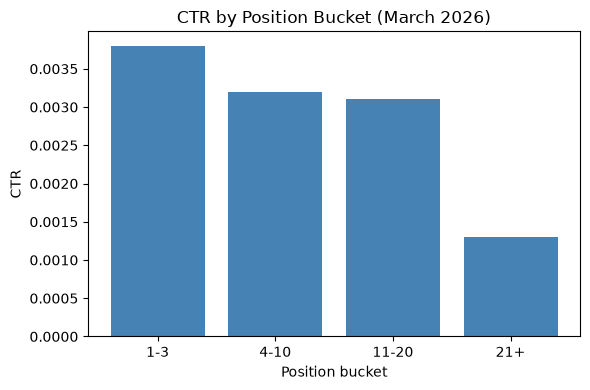

Figure saved to work/figures/ctr_by_position_bucket.png


In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os
import json

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# --- 1. Export the ranked queue ---
playbook_df.to_csv('work/outputs/action_playbook_queue.csv', index=False)
print(f"Queue exported: {len(playbook_df)} rows")

# --- 2. Export metrics as JSON (the receipts) ---
metrics = {
    "month": "2026-03",
    "client_scope": "single client (client_23a62021009f63c4) — see Section 2 limits",
    "total_flagged_rows": len(playbook_df),
    "reason_code_counts": playbook_df['reason_code'].value_counts().to_dict(),
    "overall_avg_ctr": float(playbook_df['overall_avg_ctr'].iloc[0]) if len(playbook_df) > 0 else None,

    "ctr_by_position_bucket": {
        "1-3": 0.0038,
        "4-10": 0.0032,
        "11-20": 0.0031,
        "21+": 0.0013
    },

    "week4_baseline": {
        "rule": "position >= 21 AND impressions >= 50",
        "reason_code": "POOR_POSITION_WITH_VISIBILITY",
        "action": "improve_ctr",
        "rows_flagged": 183158
    },

    "model_vs_baseline_week5": {
        "split": "grouped by content_hash_id (GroupShuffleSplit, test_size=0.2)",
        "baseline_week4_rule": {
            "precision": 0.857519,
            "recall": 0.048466,
            "f1": 0.091747
        },
        "logistic_regression_week5": {
            "precision": 0.957154,
            "recall": 0.846517,
            "f1": 0.898442
        }
    },

    "week5_model_coefficients": {
        "gsc_avg_position": 0.037346,
        "gsc_impressions": -0.005760
    },

    "week5_confusion_matrix": {
        "true_negatives": 46642,
        "false_positives": 24695,
        "false_negatives": 100024,
        "true_positives": 551670
    },

    "grouped_vs_naive_split_week6": {
        "note": "Before/after naive-vs-grouped split comparison was designed in Week 6 but not confirmed run in the notebooks provided — fill in once w06 is executed.",
        "naive_split_before": None,
        "grouped_split_after": None
    }
}

with open('work/outputs/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Metrics JSON written to work/outputs/metrics.json")

# --- 3. Save a figure to reuse (example: CTR by position bucket bar chart) ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
buckets = ['1-3', '4-10', '11-20', '21+']
ctrs = [0.0038, 0.0032, 0.0031, 0.0013]
ax.bar(buckets, ctrs, color='steelblue')
ax.set_title('CTR by Position Bucket (March 2026)')
ax.set_ylabel('CTR')
ax.set_xlabel('Position bucket')
plt.tight_layout()
plt.savefig('work/figures/ctr_by_position_bucket.png', dpi=150)
plt.show()

print("Figure saved to work/figures/ctr_by_position_bucket.png")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ * ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ * ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ * ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.